In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mushroom.csv to mushroom.csv


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
data = pd.read_csv('/content/mushroom.csv')

In [6]:
data.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [7]:
data=data.drop('Unnamed: 0', axis=1)

In [8]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cap_shape                 2000 non-null   object 
 1   cap_surface               2000 non-null   object 
 2   cap_color                 2000 non-null   object 
 3   bruises                   2000 non-null   object 
 4   odor                      2000 non-null   object 
 5   gill_attachment           2000 non-null   object 
 6   gill_spacing              2000 non-null   object 
 7   gill_size                 2000 non-null   object 
 8   gill_color                2000 non-null   object 
 9   stalk_shape               2000 non-null   object 
 10  stalk_root                2000 non-null   object 
 11  stalk_surface_above_ring  2000 non-null   object 
 12  stalk_surface_below_ring  2000 non-null   object 
 13  stalk_color_above_ring    2000 non-null   object 
 14  stalk_co

In [10]:

cols = [c for c in data.columns if c != 'class'] + ['class']
data = data[cols]

# Verify it worked
print("New Column Order:")
data.head()

New Column Order:


,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,stalk_height,cap_diameter,class
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,14.276173,5.054983,poisonous
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,3.952715,19.068319,edible
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,9.054265,7.205884,poisonous
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,5.226499,20.932692,poisonous
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,14.037532,12.545245,poisonous


In [12]:
numerical_cols = data.select_dtypes(include=['float64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

/tmp/ipython-input-1579098056.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=col, x='class', data=data, palette='Set2')
/tmp/ipython-input-1579098056.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=col, x='class', data=data, palette='Set2')


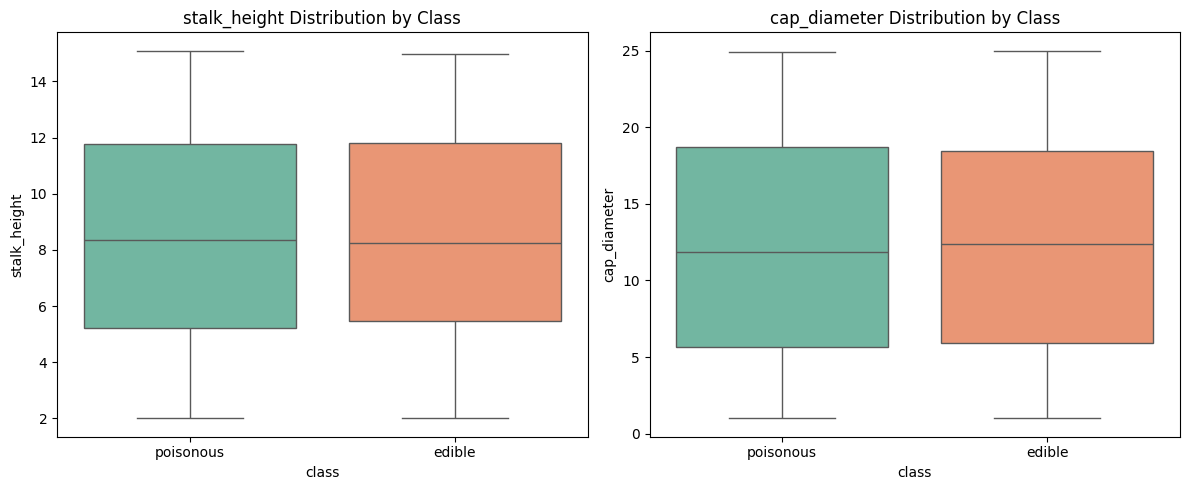

In [14]:
#Boxplot for numerical columns
plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i+1)
    sns.boxplot(y=col, x='class', data=data, palette='Set2')
    plt.title(f'{col} Distribution by Class')
plt.tight_layout()
plt.show()

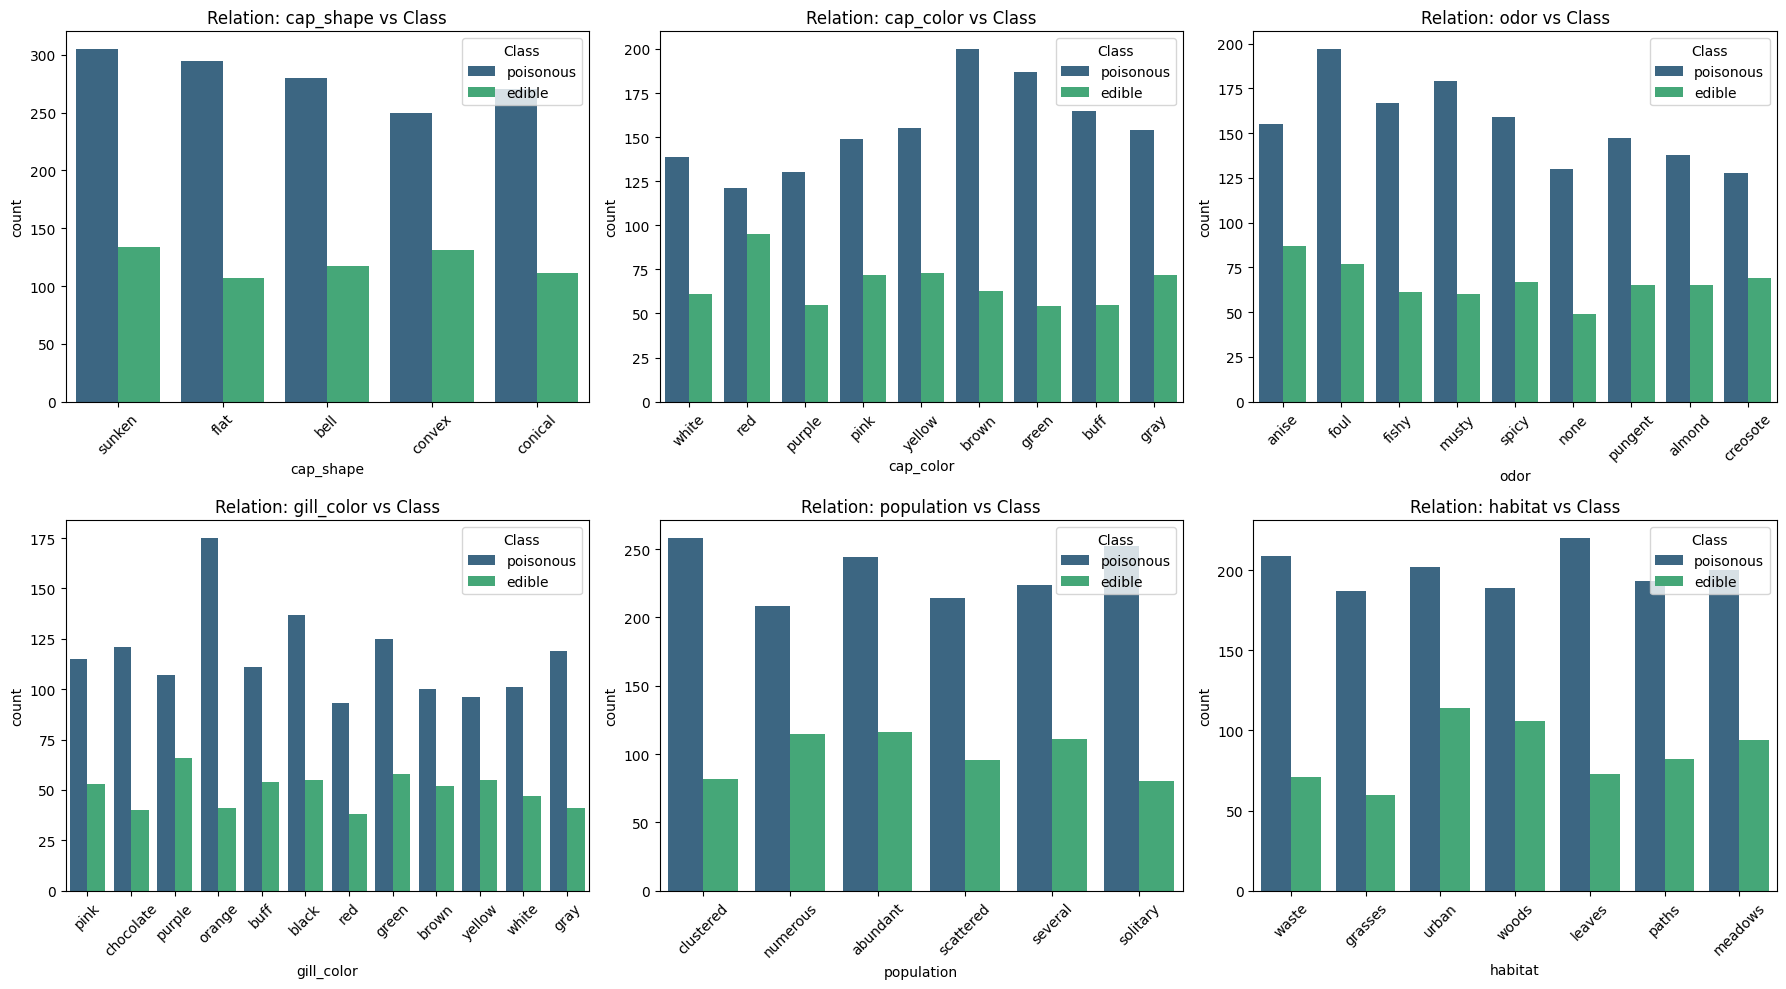

In [20]:
# Select just the most visually interesting features for the report
# (Plotting all 22 columns makes the graph unreadable)
selected_cats = ['cap_shape', 'cap_color', 'odor', 'gill_color', 'population', 'habitat']

plt.figure(figsize=(18, 10)) # Big canvas

for i, col in enumerate(selected_cats):
    plt.subplot(2, 3, i+1) # 2 Rows, 3 Columns
    sns.countplot(x=col, hue='class', data=data, palette='viridis')
    plt.title(f'Relation: {col} vs Class')
    plt.xticks(rotation=45)
    plt.legend(title='Class', loc='upper right')

plt.tight_layout()
plt.show()

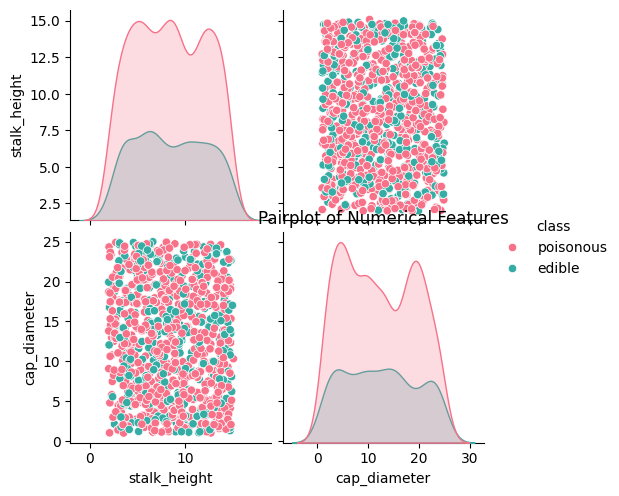

In [22]:
sns.pairplot(data, hue='class', vars=numerical_cols, palette='husl')
plt.title('Pairplot of Numerical Features')
plt.show()

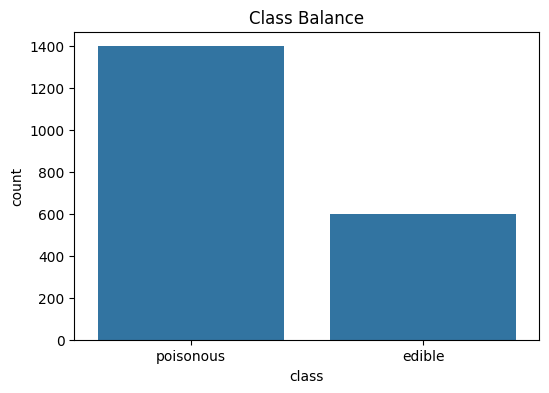

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=data)
plt.title('Class Balance')
plt.show()

Class imbalance is there, will treat it before training the model

In [26]:
label_encoders = {}
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le

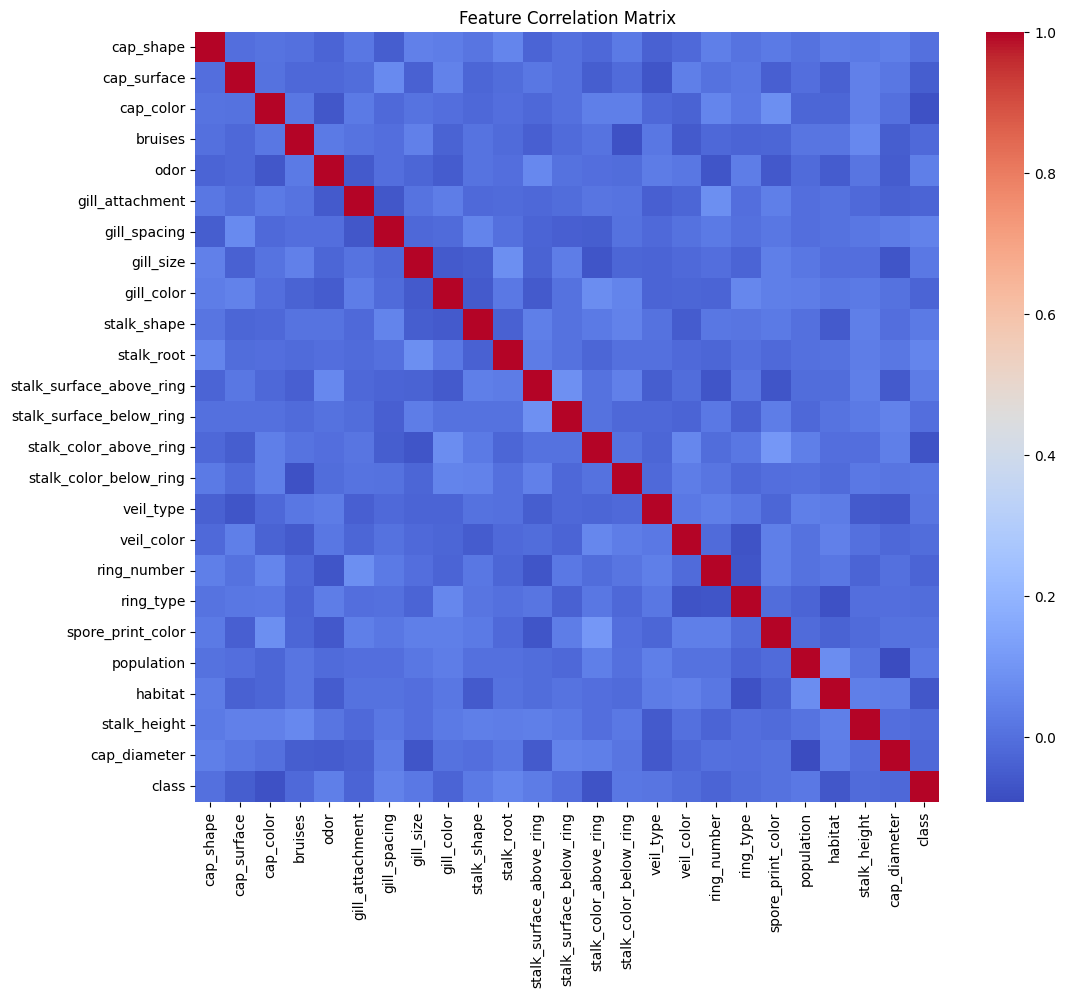

In [29]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.show()

We can observe weak correlation

In [30]:
X = data.drop('class', axis=1)
y = data['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear', random_state=42)

In [32]:
y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5466666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.53      0.42       185
           1       0.73      0.55      0.63       415

    accuracy                           0.55       600
   macro avg       0.54      0.54      0.52       600
weighted avg       0.61      0.55      0.56       600



Low accuracy lets change the kernel


In [34]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
model = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', C=10, gamma='scale'))
model.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=10, class_weight='balanced'))])

In [36]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.865

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.73      0.77       185
           1       0.88      0.93      0.90       415

    accuracy                           0.86       600
   macro avg       0.85      0.83      0.84       600
weighted avg       0.86      0.86      0.86       600



In [38]:
model = make_pipeline(StandardScaler(), SVC(kernel='poly', class_weight='balanced', C=10, gamma='scale'))
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=10, class_weight='balanced', kernel='poly'))])

In [39]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8516666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.74      0.75       185
           1       0.89      0.90      0.89       415

    accuracy                           0.85       600
   macro avg       0.83      0.82      0.82       600
weighted avg       0.85      0.85      0.85       600



Initially, the Linear Kernel performed poorly (Accuracy: ~55%), indicating that the decision boundary between edible and poisonous mushrooms in this dataset is not linear. By switching to the Radial Basis Function (RBF) Kernel and applying StandardScaler, the model successfully captured the non-linear relationships, boosting accuracy to 86%. This proves that features like stalk_height and cap_shape interact in complex ways that a simple straight line cannot separate.